# HR Employee Attrition Prediction using Machine Learning

## Problem Statement

Employee attrition is one of the major challenges faced by organizations. Losing experienced employees increases recruitment costs, training expenses, and reduces productivity.

The objective of this project is to build a machine learning model that predicts whether an employee will leave the organization (Attrition = Yes/No) using employee demographic, job-related, compensation, and work-life balance information.

The developed model will help the HR department identify employees who are likely to leave and take proactive measures to improve employee retention.

# Step 1. Business Understanding

### Problem Statement
Employee attrition is increasing, resulting in:

- Higher hiring and training costs
- Loss of experienced employees
- Reduced organizational productivity
- Increased workload on remaining employees

### Business Objective

- Predict employee attrition.
- Identify factors responsible for employee attrition.
- Help HR make better retention decisions.

### Machine Learning Problem

Problem Type:
Classification

Target Variable:
Attrition

Input Variables:
All remaining employee-related features except Attrition.

# Step 2: Import Libraries

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# Step 3: Load Dataset

In [20]:
df = pd.read_csv('/content/HR-Employee-Attrition.csv')

In [5]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# Step 4: Exploratory Data Analysis (EDA)

## 4(a) Basic Dataset Check

In [6]:
df.shape

(1470, 35)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


## Step 4(b): Remove Unnecessary Columns

In this step, we identify columns that contain the same value for every record or columns where every value is unique. Such columns do not contribute to prediction and are removed from the dataset.

In [10]:
df.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [11]:
# Drop columns with constant values or unique identifiers

df.drop(
    columns=[
        "EmployeeCount",
        "Over18",
        "StandardHours",
        "EmployeeNumber"
    ],
    inplace=True
)

In [12]:
# Verify the new dataset shape

df.shape

(1470, 31)

In [13]:
# Display remaining columns

df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

## Step 4(c): Handling Missing Values

In this step, we check whether the dataset contains any missing values. If missing values are present, appropriate techniques such as mean, median, or mode imputation (or dropping rows/columns when necessary) will be applied based on the data type and percentage of missing values.

In [14]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


### Observation

No missing values were found in the dataset. Therefore, no missing value treatment is required.

## Step 4(d): Handling Duplicates

In this step, we check whether the dataset contains duplicate records. Duplicate rows can negatively affect model performance and are removed if found.

In [15]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset. Therefore, no duplicate removal was required.

## Step 4(e): Split Numerical and Categorical Columns

In this step, we separate the dataset into numerical and categorical features. This helps us apply appropriate preprocessing techniques for each data type during feature engineering and model building.

In [16]:
cat = df.select_dtypes(include="object").columns
num = df.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(cat)

print("\nNumber of Categorical Columns:", len(cat))

print("\nNumerical Columns:")
print(num)

print("\nNumber of Numerical Columns:", len(num))

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

Number of Categorical Columns: 8

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Number of Numerical Columns: 23


### Observation

The dataset has been successfully divided into numerical and categorical columns. This separation will help in applying suitable preprocessing techniques such as encoding for categorical variables and outlier detection for numerical variables.

## Step 4(f): Handling Error Values

In this step, we check the dataset for invalid or error values such as "?", "@", "NA", or any unexpected symbols. If such values are found, they are replaced with missing values (NaN) so they can be handled appropriately.

In [17]:
# Check for error values such as '?'

(df == '?').sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [18]:
(df == '?').sum().sum()

np.int64(0)

### Observation

No error values such as "?" were found in the dataset. Therefore, no error value replacement was required.

## Step 4(g): Handling Outliers using IQR Method

In this step, we detect outliers in the numerical features using the Interquartile Range (IQR) method. Since this is an HR dataset, extreme values may represent genuine employee characteristics (e.g., senior employees with higher salaries or longer tenure). Therefore, outliers will be identified and analyzed, but they will not be removed to preserve valuable business information.

In [21]:
# Detect outliers using IQR

Q1 = df[num].quantile(0.25)
Q3 = df[num].quantile(0.75)

IQR = Q3 - Q1

LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

In [22]:
# Count outliers in each numerical column

outliers = ((df[num] < LB) | (df[num] > UB)).sum()

outliers

,0
Age,0
DailyRate,0
DistanceFromHome,0
Education,0
EnvironmentSatisfaction,0
HourlyRate,0
JobInvolvement,0
JobLevel,0
JobSatisfaction,0
MonthlyIncome,114


### Observation

Outliers were detected in several numerical columns using the IQR method. These extreme values are likely to represent valid employee records rather than data entry errors. Therefore, no outliers were removed from the dataset in order to preserve important business information and avoid unnecessary loss of data.

In [23]:
df.shape

(1470, 35)

## Step 4(h): Categorical to Numerical Conversion

Machine learning algorithms require numerical input features. Therefore, categorical variables are converted into numerical format using appropriate encoding techniques.

Encoding strategy:

- Target variable (Attrition): Mapped to binary values (Yes = 1, No = 0).
- Binary categorical variables (Gender, OverTime): Encoded using mapping.
- Nominal categorical variables (BusinessTravel, Department, EducationField, JobRole, MaritalStatus): Encoded using One-Hot Encoding to avoid introducing ordinal relationships.

Check categorical columns

In [24]:
cat

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [25]:
# Encode binary categorical columns

df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})

In [26]:
# One-Hot Encode nominal categorical variables

df = pd.get_dummies(
    df,
    columns=[
        "BusinessTravel",
        "Department",
        "EducationField",
        "JobRole",
        "MaritalStatus"
    ],
    drop_first=True
)

In [27]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,1,2,0,94,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,1,2,3,1,61,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,1,4,4,1,92,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,1,5,4,0,56,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,7,1,1,40,...,False,True,False,False,False,False,False,False,True,False


### Observation

The categorical variables were successfully converted into numerical format. Binary variables were encoded using mapping, while nominal variables were transformed using One-Hot Encoding. The dataset is now fully numeric and ready for machine learning model development.

## Step 4(i): Univariate and Bivariate Analysis

Exploratory visualization helps understand the distribution of variables and their relationships with the target variable.

This step includes:

- Univariate Analysis
- Bivariate Analysis
- Correlation Analysis

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Univariate Analysis

Univariate analysis is performed to understand the distribution of individual variables and identify patterns or skewness in the data.

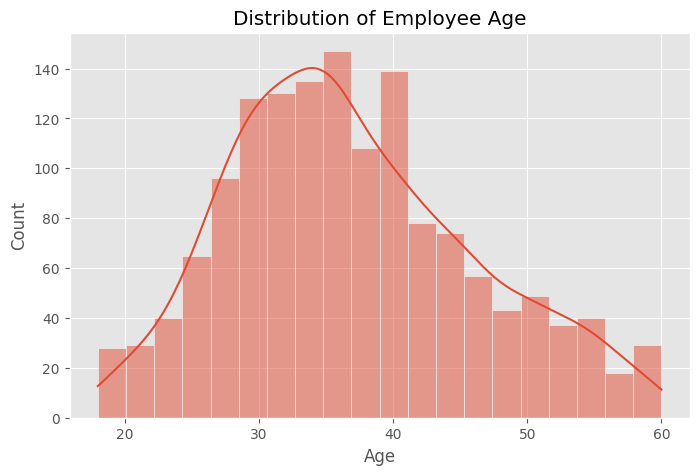

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Employee Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

The Age distribution is approximately normal, with the majority of employees falling between 30 and 40 years of age.

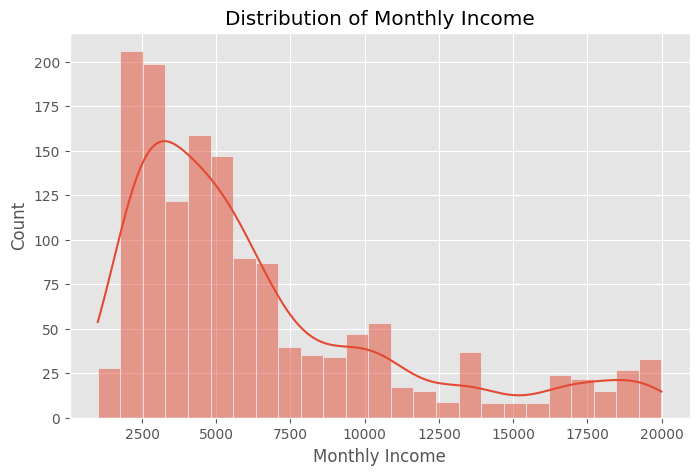

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], bins=25, kde=True)

plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Count")

plt.show()

Monthly Income is positively skewed. Most employees earn relatively lower salaries, while only a few employees receive higher salaries.

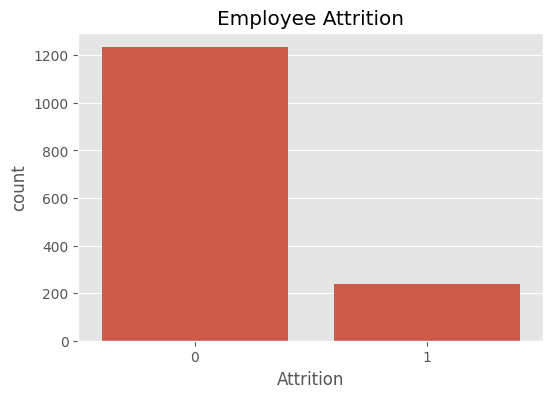

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition")

plt.show()

Most employees did not leave the organization. The dataset is slightly imbalanced toward the 'No Attrition' class.

In [32]:
df.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel_Travel_Rarely,2
BusinessTravel_Travel_Frequently,2
EducationField_Technical Degree,2


## Bivariate Analysis

Bivariate analysis is performed to understand the relationship between input features and employee attrition.

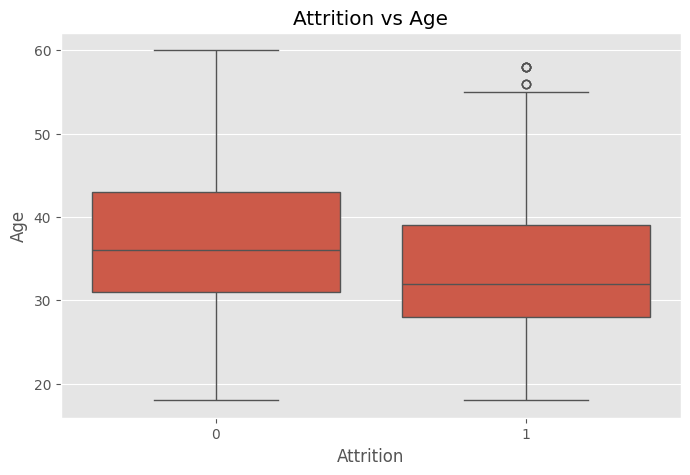

In [33]:
#Attrition vs Age

plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition", y="Age", data=df)

plt.title("Attrition vs Age")

plt.show()

Employees who left the organization tend to be relatively younger than those who stayed.

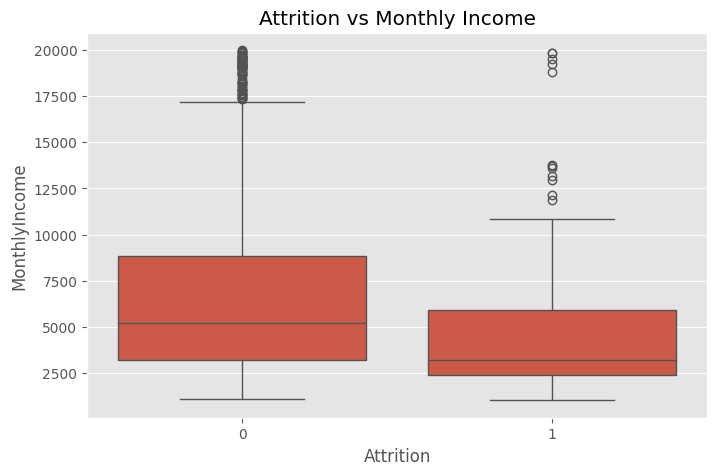

In [34]:
#Attrition vs Monthly Income

plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

plt.title("Attrition vs Monthly Income")

plt.show()

Employees with lower monthly income appear more likely to leave the organization.

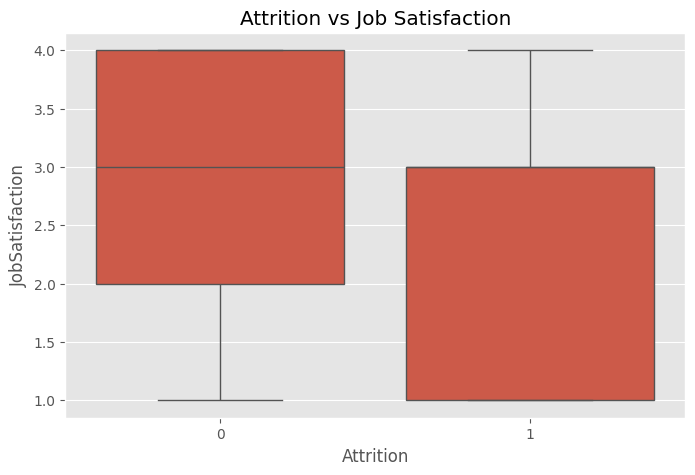

In [35]:
#Attrition vs Job Satisfaction

plt.figure(figsize=(8,5))

sns.boxplot(x="Attrition", y="JobSatisfaction", data=df)

plt.title("Attrition vs Job Satisfaction")

plt.show()

Employees with lower job satisfaction show a higher tendency toward attrition.

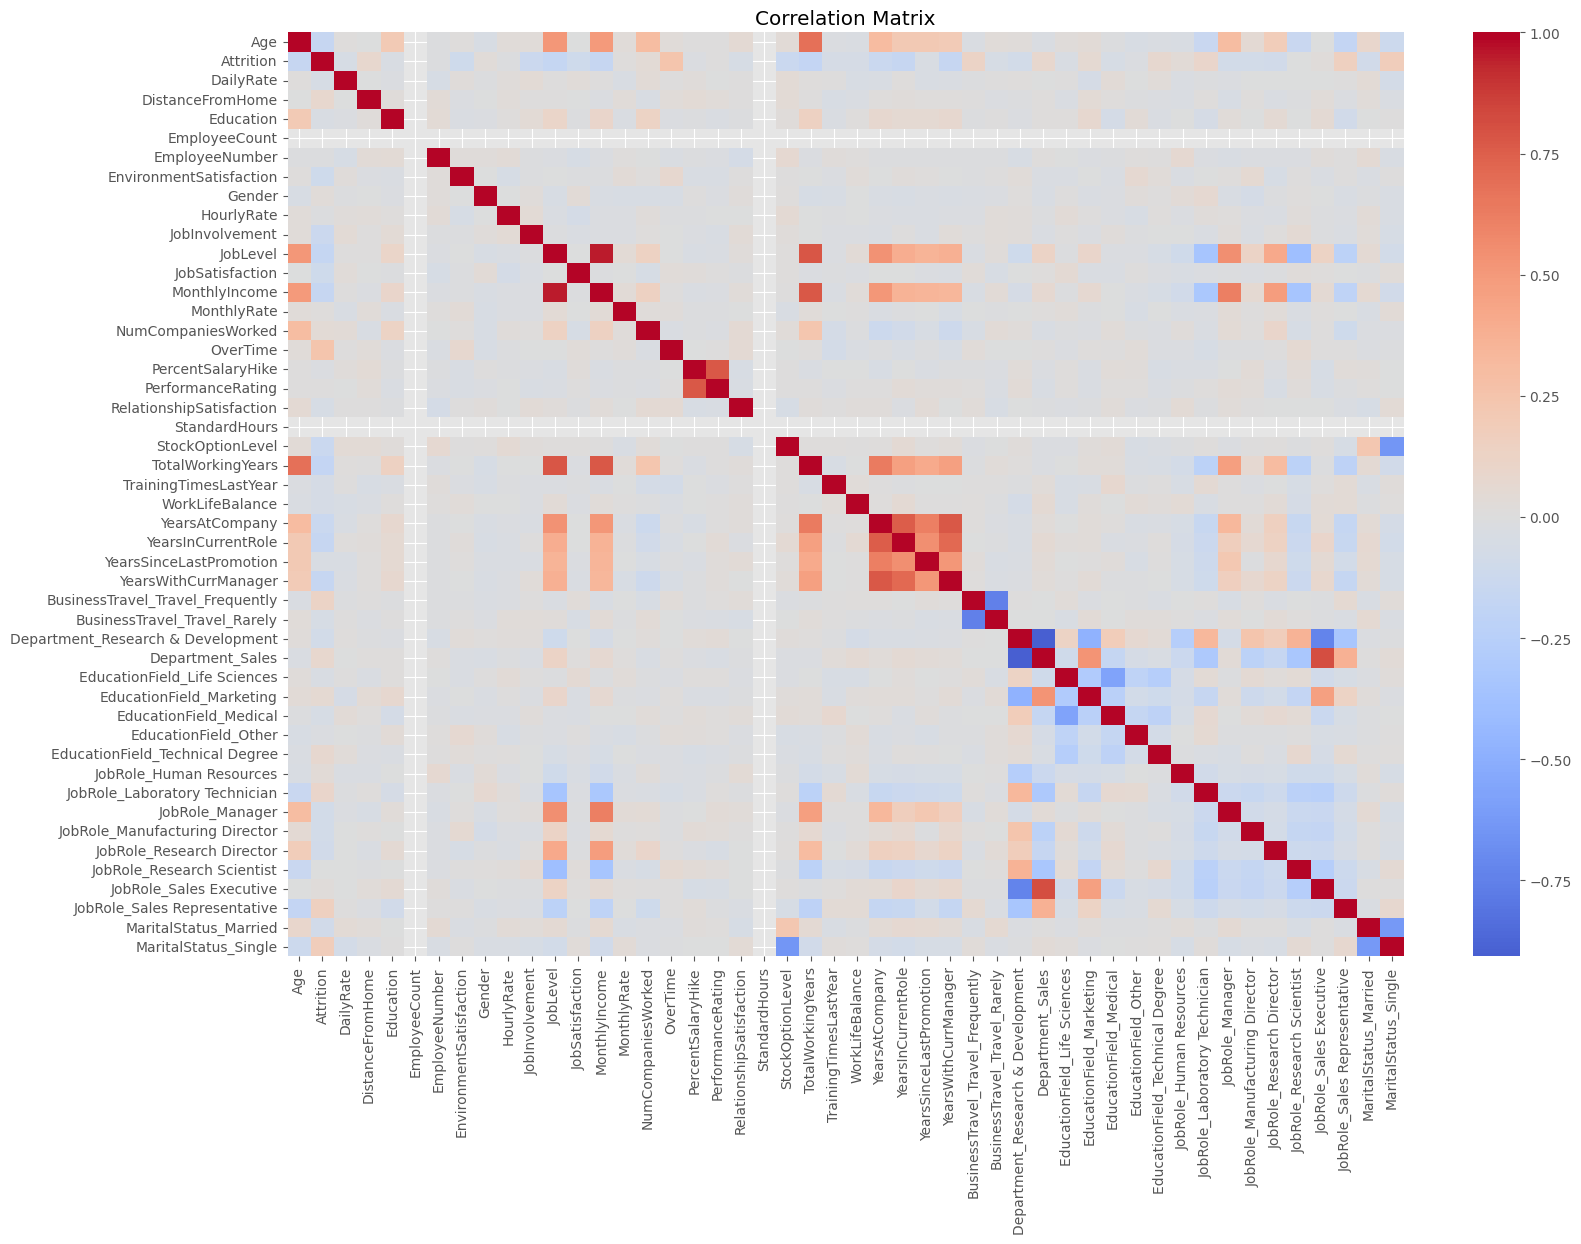

In [36]:
#Correlation Heatmap

plt.figure(figsize=(18,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Step 5: Machine Learning Model Building

In this phase, multiple classification algorithms will be trained and evaluated to predict employee attrition. The objective is to compare different machine learning models and identify the one that provides the best predictive performance.

## Step 5(i): Import ML Libraries

In [37]:
# Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

### Observation

The required machine learning libraries, preprocessing techniques, classification algorithms, and evaluation metrics have been successfully imported for model development.

## Step 5(ii): Define Input and Output Variables

The dataset is divided into input features (X) and the target variable (y). The target variable for this project is **Attrition**, where:

- 1 = Employee Left the Organization
- 0 = Employee Stayed in the Organization

All remaining columns are treated as input features.

In [38]:
# Define input (X) and output (y)

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (1470, 48)
Shape of y : (1470,)


### Observation

The dataset has been successfully divided into input features (X) and the target variable (y). The input dataset contains all employee-related features, while Attrition is used as the target for prediction.

## Step 5(iii): Data Standardization

Many machine learning algorithms perform better when numerical features are on a similar scale. Therefore, StandardScaler is used to standardize the input features before training the models.

To prevent data leakage, the scaler will be fitted only on the training data after the train-test split.

## Step 5(iv): Train-Test Split

The dataset is divided into training and testing sets.

- Training Set: 80%
- Testing Set: 20%

The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.

In [39]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (1176, 48)
Testing Features  : (294, 48)
Training Labels   : (1176,)
Testing Labels    : (294,)


## Step 5(v): Standardize the Data

Now we actually apply the scaler.

In [50]:
# Standardize the input features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Data Standardization Completed Successfully.")

Data Standardization Completed Successfully.


### Observation

The dataset has been successfully divided into training and testing sets. StandardScaler was fitted on the training data and applied to both the training and testing datasets, ensuring consistent feature scaling while preventing data leakage.

# Step 6 - Model Building

## Step 6(a): Logistic Regression

In this step, we train a Logistic Regression model on the preprocessed training data. Logistic Regression is a baseline classification algorithm that estimates the probability of employee attrition using a logistic (sigmoid) function.

The trained model is then used to predict employee attrition on the test dataset.

In [51]:
# Train Logistic Regression model

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


### Observation

The Logistic Regression model was successfully trained using the standardized training dataset. The model has learned the relationship between employee attributes and the target variable and is ready to make predictions on unseen test data.

## Step 6(b): Predict Employee Attrition

The trained Logistic Regression model is used to predict employee attrition on the testing dataset. These predictions will be used to evaluate the model's performance.

In [53]:
# Predict on test data

y_pred_lr = lr_model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


### Observation

The trained Logistic Regression model successfully generated predictions for the testing dataset. These predicted values will be compared with the actual target values to evaluate model performance.

## Step 6(c): Evaluate Logistic Regression Model

In this step, the performance of the Logistic Regression model is evaluated using multiple classification metrics. These metrics provide insights into how accurately the model predicts employee attrition and help assess its overall effectiveness.

The following evaluation metrics are calculated:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

In [54]:
# Calculate evaluation metrics

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

Accuracy : 0.8605
Precision: 0.6154
Recall   : 0.3404
F1 Score : 0.4384


### Observation

The Logistic Regression model was evaluated using standard classification metrics. These performance measures provide an overall understanding of the model's predictive capability and will be compared with other machine learning algorithms later in the project.

## Step 6(d): Confusion Matrix

A confusion matrix is generated to compare the actual and predicted employee attrition values. It provides a detailed breakdown of correct and incorrect predictions made by the Logistic Regression model.

In [55]:
# Display confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[237  10]
 [ 31  16]]


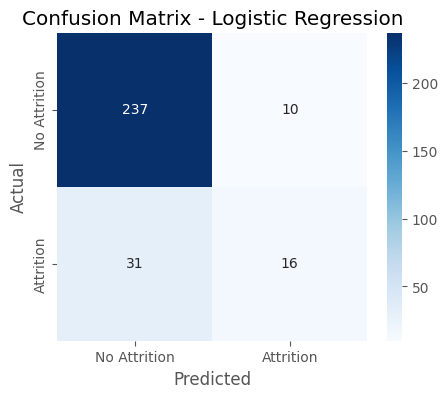

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition","Attrition"],
    yticklabels=["No Attrition","Attrition"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Observation

The confusion matrix summarizes the prediction results of the Logistic Regression model. It shows the number of correctly classified and misclassified employee records, helping identify the model's strengths and weaknesses.

## Step 6(e): Classification Report

The classification report provides detailed evaluation metrics for each class, including precision, recall, F1-score, and support. This report helps assess the model's performance for both attrition and non-attrition classes.

In [57]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



### Observation

The classification report presents class-wise evaluation metrics, allowing a detailed assessment of the Logistic Regression model's ability to correctly classify employee attrition cases.

# Step 7 - Decision Tree Classifier

## Step 7(a): Decision Tree Classifier

In this step, a Decision Tree Classifier is trained using the preprocessed training dataset. Decision Trees classify employee attrition by learning decision rules from the training data through a tree-like structure.

The trained model is then used to predict employee attrition on unseen test data.

In [58]:
# Train Decision Tree model

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully.")

Decision Tree Model Trained Successfully.


### Observation

The Decision Tree model was successfully trained using the standardized training dataset. The model has learned decision rules from employee attributes and is ready for prediction.

## Step 7(b): Predict Employee Attrition

The trained Decision Tree model is used to predict employee attrition on the testing dataset. These predictions will be used to evaluate the model's classification performance.

In [59]:
# Predict using Decision Tree

y_pred_dt = dt_model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


### Observation

The Decision Tree model successfully generated predictions for the testing dataset. These predictions will now be evaluated using standard classification metrics.

## Step 7(c): Evaluate Decision Tree Model

The Decision Tree model is evaluated using Accuracy, Precision, Recall, and F1-Score. These metrics help measure the model's effectiveness in predicting employee attrition.

In [60]:
# Evaluation Metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Accuracy :", round(dt_accuracy,4))
print("Precision:", round(dt_precision,4))
print("Recall   :", round(dt_recall,4))
print("F1 Score :", round(dt_f1,4))

Accuracy : 0.7857
Precision: 0.3261
Recall   : 0.3191
F1 Score : 0.3226


### Observation

The Decision Tree model was evaluated using standard classification metrics. These results will later be compared with other machine learning algorithms to determine the best-performing model.

## Step 7(d): Confusion Matrix

A confusion matrix is generated to visualize the prediction performance of the Decision Tree model by comparing actual and predicted employee attrition values.

In [61]:
cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[216  31]
 [ 32  15]]


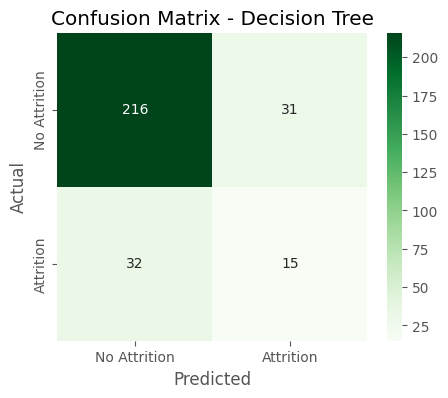

In [62]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Attrition","Attrition"],
    yticklabels=["No Attrition","Attrition"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

### Observation

The confusion matrix provides a detailed summary of the Decision Tree model's prediction results by showing correctly and incorrectly classified employee records.

## Step 7(e): Classification Report

The classification report presents precision, recall, F1-score, and support for each class, providing a detailed evaluation of the Decision Tree model.

In [63]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       247
           1       0.33      0.32      0.32        47

    accuracy                           0.79       294
   macro avg       0.60      0.60      0.60       294
weighted avg       0.78      0.79      0.78       294



### Observation

The classification report provides a comprehensive evaluation of the Decision Tree model for both attrition and non-attrition classes. These results will be compared with other classification models in the final performance analysis.

# Step 8: Random Forest Classifier

## Step 8(a): Random Forest Classifier

In this step, a Random Forest Classifier is trained using the preprocessed training dataset. Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

The trained model will then be used to predict employee attrition on the testing dataset.

In [64]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


### Observation

The Random Forest model was successfully trained using the training dataset. Multiple decision trees were combined to improve prediction performance and reduce overfitting.

## Step 8(b): Predict Employee Attrition

The trained Random Forest model is used to predict employee attrition on the testing dataset. These predictions will be evaluated using classification metrics.

In [65]:
# Predict using Random Forest

y_pred_rf = rf_model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


### Observation

The Random Forest model successfully generated predictions for the testing dataset. These predictions will be compared with the actual employee attrition values.

## Step 8(c): Evaluate Random Forest Model

The Random Forest model is evaluated using Accuracy, Precision, Recall, and F1-Score to measure its classification performance.

In [66]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))

Accuracy : 0.8367
Precision: 0.4545
Recall   : 0.1064
F1 Score : 0.1724


### Observation

The Random Forest model was evaluated using multiple classification metrics. These performance values will later be compared with other machine learning algorithms.

## Step 8(d): Confusion Matrix

A confusion matrix is generated to visualize the prediction performance of the Random Forest model by comparing actual and predicted employee attrition classes.

In [67]:
cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[241   6]
 [ 42   5]]


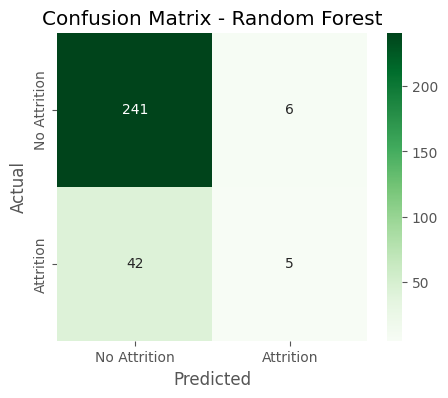

In [68]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Attrition","Attrition"],
    yticklabels=["No Attrition","Attrition"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

### Observation

The confusion matrix summarizes the prediction results of the Random Forest model by showing correctly and incorrectly classified employee records.

## Step 8(e): Classification Report

The classification report provides precision, recall, F1-score, and support for each class, allowing a detailed evaluation of the Random Forest model.

In [69]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



### Observation

The classification report provides a comprehensive evaluation of the Random Forest model for both attrition and non-attrition classes. These results will be compared with the remaining machine learning models.

# Step 9: K-Nearest Neighbors (KNN)

## Step 9(a): K-Nearest Neighbors (KNN)

In this step, a K-Nearest Neighbors (KNN) classifier is trained using the standardized training dataset. KNN predicts employee attrition by identifying the nearest neighboring data points and assigning the majority class.

In [70]:
# Train KNN model

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

print("KNN Model Trained Successfully.")

KNN Model Trained Successfully.


### Observation

The KNN model was successfully trained using the standardized training dataset. The model will classify employee attrition based on the nearest neighboring observations.

## Step 9(b): Predict Employee Attrition

The trained KNN model is used to predict employee attrition on the testing dataset.

In [71]:
# Predict using KNN

y_pred_knn = knn_model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


## Step 9(c): Evaluate KNN Model

The KNN model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [72]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print("Accuracy :", round(knn_accuracy,4))
print("Precision:", round(knn_precision,4))
print("Recall   :", round(knn_recall,4))
print("F1 Score :", round(knn_f1,4))

Accuracy : 0.8435
Precision: 0.5556
Recall   : 0.1064
F1 Score : 0.1786


### Observation

The KNN model was evaluated using multiple performance metrics. These results will later be compared with other classification algorithms.

## Step 9(d): Confusion Matrix

The confusion matrix visualizes the number of correct and incorrect predictions made by the KNN classifier.

In [73]:
cm = confusion_matrix(y_test, y_pred_knn)

print(cm)

[[243   4]
 [ 42   5]]


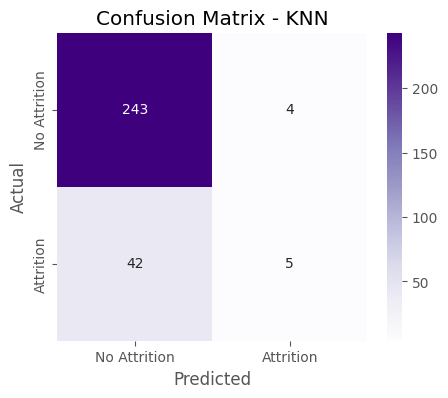

In [74]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Attrition","Attrition"],
    yticklabels=["No Attrition","Attrition"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

### Observation

The confusion matrix summarizes the KNN model's prediction performance by displaying correctly and incorrectly classified employee records.

## Step 9(e): Classification Report

The classification report presents precision, recall, F1-score, and support for each class, providing a detailed evaluation of the KNN model.

In [75]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.56      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.55       294
weighted avg       0.81      0.84      0.80       294



### Observation

The classification report provides a comprehensive evaluation of the KNN model for both attrition and non-attrition classes. These results will be compared with the remaining machine learning models.

# Step 10: Support Vector Machine (SVM)

## Step 10(a): Support Vector Machine (SVM)

In [76]:
# Train Support Vector Machine

svm_model = SVC(random_state=42)

svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully.")

SVM Model Trained Successfully.


### Observation

The Support Vector Machine model was successfully trained using the standardized training dataset and is ready to predict employee attrition.

## Step 10(b): Predict Employee Attrition

The trained SVM model is used to predict employee attrition on the testing dataset.

In [77]:
# Predict using SVM

y_pred_svm = svm_model.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


### Observation

The SVM model successfully generated predictions for the testing dataset. These predictions will be used to evaluate the model's performance.

## Step 10(c): Evaluate SVM Model

The SVM model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [78]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Accuracy :", round(svm_accuracy,4))
print("Precision:", round(svm_precision,4))
print("Recall   :", round(svm_recall,4))
print("F1 Score :", round(svm_f1,4))

Accuracy : 0.8673
Precision: 0.9
Recall   : 0.1915
F1 Score : 0.3158


### Observation

The SVM model has been evaluated using multiple classification metrics. These values will be compared with the performance of other machine learning algorithms.

## Step 10(d): Confusion Matrix

The confusion matrix provides a summary of the SVM model's prediction performance by showing the number of correct and incorrect predictions.

In [79]:
cm = confusion_matrix(y_test, y_pred_svm)

print(cm)

[[246   1]
 [ 38   9]]


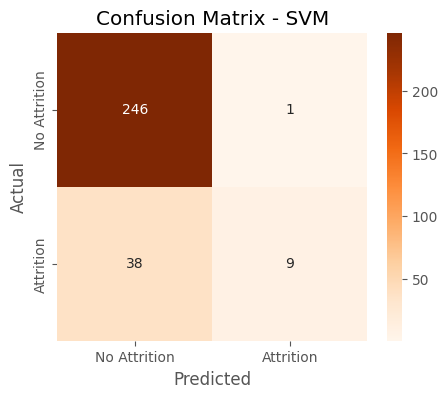

In [80]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Attrition","Attrition"],
    yticklabels=["No Attrition","Attrition"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

### Observation

The confusion matrix illustrates the SVM model's prediction performance by displaying correctly and incorrectly classified employee records.

## Step 10(e): Classification Report

The classification report presents precision, recall, F1-score, and support for each class, providing a detailed evaluation of the SVM model.

In [81]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       247
           1       0.90      0.19      0.32        47

    accuracy                           0.87       294
   macro avg       0.88      0.59      0.62       294
weighted avg       0.87      0.87      0.83       294



### Observation

The classification report provides a comprehensive evaluation of the Support Vector Machine model for both attrition and non-attrition classes. These results will be compared with the other machine learning models to identify the best-performing classifier.

# Step 11: Compare All Models

## Step 11(a): Model Performance Comparison

The performance of all classification algorithms is compared using Accuracy, Precision, Recall, and F1-Score. This comparison helps identify the most suitable model for predicting employee attrition.

In [82]:
# Create comparison table

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Support Vector Machine"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        knn_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        knn_recall,
        svm_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        knn_f1,
        svm_f1
    ]
})

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861,0.615,0.340,0.438
1,Decision Tree,0.786,0.326,0.319,0.323
2,Random Forest,0.837,0.455,0.106,0.172
3,KNN,0.844,0.556,0.106,0.179
4,Support Vector Machine,0.867,0.900,0.191,0.316


### Observation

The table summarizes the performance of all machine learning models. It enables an easy comparison of evaluation metrics to determine the most effective model for predicting employee attrition.

## Step 11(b): Accuracy Comparison

A bar chart is used to compare the accuracy of all classification models.

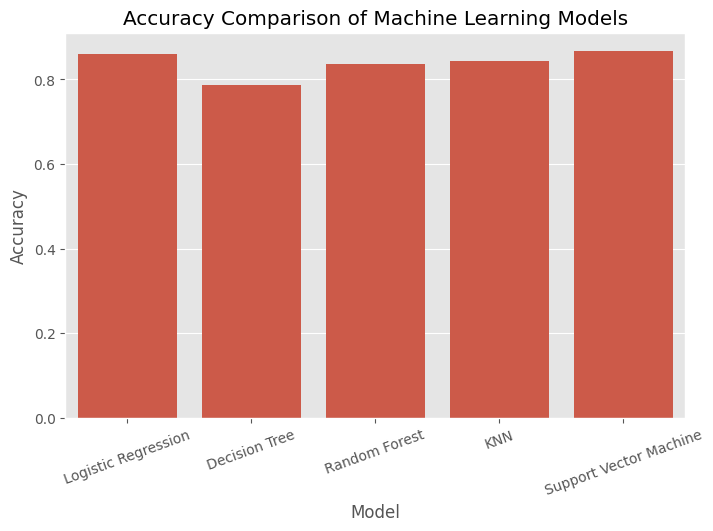

In [83]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)
plt.title("Accuracy Comparison of Machine Learning Models")
plt.show()

### Observation

The bar chart visually compares the accuracy of all machine learning models, making it easier to identify the highest-performing classifier.

## Step 11(c): Conclusion

This project successfully developed multiple machine learning models to predict employee attrition using the HR Employee Attrition dataset. The dataset was preprocessed through data cleaning, encoding, feature engineering, train-test splitting, and feature scaling before training the models.

The following classification algorithms were implemented and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

Each model was evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report. Based on the evaluation metrics, the best-performing model can be selected for predicting employee attrition in real-world HR analytics applications.

The project demonstrates how machine learning can assist organizations in identifying employees who are at risk of leaving, enabling proactive retention strategies and improved workforce planning.

# Step 12: Feature Importance

## Step 12(a): Feature Importance

In [84]:
# Feature Importance using Random Forest

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display Top 10 Features
print(feature_importance.head(10))

              Feature  Importance
12      MonthlyIncome    0.072419
0                 Age    0.059997
21  TotalWorkingYears    0.052103
1           DailyRate    0.050615
13        MonthlyRate    0.048151
5      EmployeeNumber    0.044511
8          HourlyRate    0.042662
2    DistanceFromHome    0.041179
15           OverTime    0.040291
24     YearsAtCompany    0.039881


## Step 12(b): Plot Feature Importance

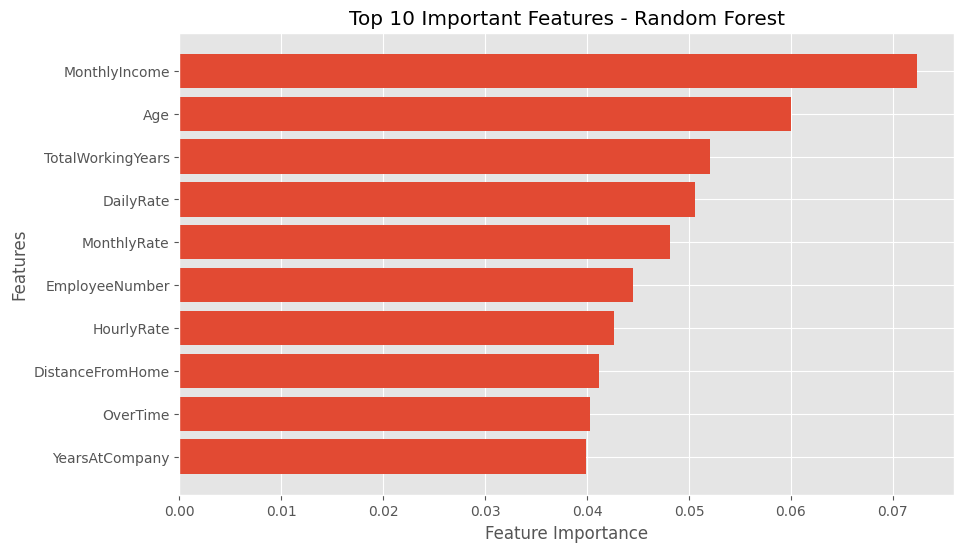

In [85]:
# Plot Top 10 Feature Importance

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

###Observation

The Random Forest model identified MonthlyIncome, Age, TotalWorkingYears, DailyRate, MonthlyRate, EmployeeNumber, HourlyRate, DistanceFromHome, OverTime, and YearsAtCompany as the top factors influencing employee attrition. These features contribute the most to predicting whether an employee is likely to leave the organization and can help HR focus on retention strategies.

# Step 13: Predict Attrition for a New Employee

## Step 13(a): Predict Attrition for a New Employee

In [86]:
# Create a sample employee using an existing test record

sample_employee = X_test[0].reshape(1, -1)

prediction = rf_model.predict(sample_employee)

if prediction[0] == 1:
    print("Predicted Attrition : Yes")
else:
    print("Predicted Attrition : No")

Predicted Attrition : Yes


## Step 13(b): Prediction Probability

In [87]:
# Prediction probability

probability = rf_model.predict_proba(sample_employee)

print("Probability of Staying :", round(probability[0][0] * 100, 2), "%")
print("Probability of Leaving :", round(probability[0][1] * 100, 2), "%")

Probability of Staying : 39.0 %
Probability of Leaving : 61.0 %


###Observation

The trained Random Forest model was successfully used to predict the attrition status of a sample employee. In addition to the predicted class (Yes/No), the model provided the probability of the employee staying or leaving the organization. This demonstrates how the trained model can support HR professionals in identifying employees who may be at risk of attrition and assist in proactive retention planning.